In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#for logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,classification_report


In [147]:
df=pd.read_csv('Data/heart_disease_prediction.csv')
df.head(3)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0


In [148]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [149]:
df['Sex'].unique()

array(['M', 'F'], dtype=object)

In [150]:
gender_id={
    'M':0,
    'F':1
}
df['Gender_id']=df['Sex'].map(gender_id)

In [ ]:
df['ChestPainType'].unique()

array(['ATA', 'NAP', 'ASY', 'TA'], dtype=object)

In [152]:
cpt_id={
    'ATA':0,
    'NAP':1,
    'ASY':2,
    'TA':3
}
df['ChestPainType_id']=df['ChestPainType'].map(cpt_id)

In [153]:
df['RestingECG'].unique()

array(['Normal', 'ST', 'LVH'], dtype=object)

In [154]:
re_id={
    'Normal':0,
    'ST':1,
    'LVH':2
}
df['RestingECG_id']=df['RestingECG'].map(re_id)

In [155]:
df['ExerciseAngina'].unique()

array(['N', 'Y'], dtype=object)

In [156]:
ea_id={
    'N':0,
    'Y':1
}
df['ExerciseAngina_id']=df['ExerciseAngina'].map(ea_id)

In [157]:
df['ST_Slope'].unique()

array(['Up', 'Flat', 'Down'], dtype=object)

In [158]:
ss_id={
    'Up': 0, 
    'Flat': 1, 
    'Down': 2
}
df['ST_Slope_id']=df['ST_Slope'].map(ss_id)

In [159]:
features=['Age','Gender_id','ChestPainType_id','RestingBP','Cholesterol',
          'FastingBS','RestingECG_id','MaxHR','ExerciseAngina_id','Oldpeak','ST_Slope_id']


In [160]:
target='HeartDisease'
x=df[features]
y=df[target]

In [161]:
x_train, x_test, y_train, y_test = train_test_split(
        x,y, test_size=0.2, random_state=42, stratify=y
)

In [162]:
# fetures scaling
scalar=StandardScaler()
x_train_scale=scalar.fit_transform(x_train)#learn+ impleemt
x_test_scale=scalar.transform(x_test) #implemet


In [163]:
# model traiing, fitting data and predit
model =LogisticRegression(
    class_weight="balanced",solver='liblinear', random_state=42
)
model.fit(x_train_scale, y_train)
y_pred=model.predict(x_test_scale)

In [168]:
print(classification_report(y_test, y_pred))
cr =classification_report(y_test, y_pred)


              precision    recall  f1-score   support

           0       0.86      0.85      0.86        82
           1       0.88      0.89      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.88      0.87       184



In [170]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[70 12]
 [11 91]]


<Axes: >

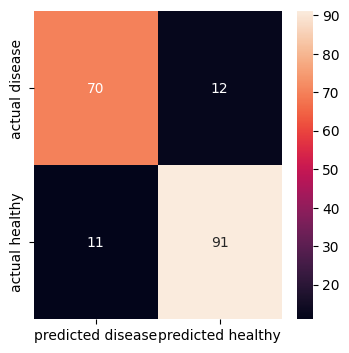

In [ ]:
#heatmap -> corelation diagram
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True ,xticklabels=['predicted disease','predicted healthy'],
             yticklabels=['actual disease','actual healthy'])
  

In [183]:
# KNN -> K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier 
error_rate=[]
k_range= range(1,21)
for i in k_range:
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train_scale, y_train)
    knn_pred=knn.predict(x_test_scale)
    error_rate.append(np.mean(y_test!=knn_pred))

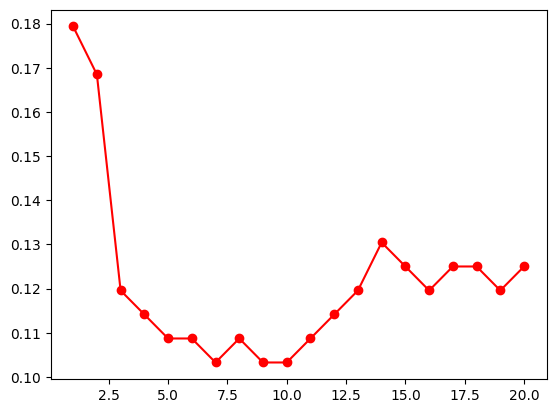

In [184]:
plt.plot(k_range, error_rate, c='red' ,marker='o')


In [185]:
k_model=KNeighborsClassifier(n_neighbors=7)
k_model.fit(x_train_scale,y_train)
k_pred=k_model.predict(x_test_scale)


In [186]:
k_cr=classification_report(y_test,k_pred)
k_cm=confusion_matrix(y_test, k_pred)
print(k_cm)

[[70 12]
 [ 7 95]]


In [187]:
print(k_cr)

              precision    recall  f1-score   support

           0       0.91      0.85      0.88        82
           1       0.89      0.93      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.89       184
weighted avg       0.90      0.90      0.90       184



knn does better prediction than logistic regresision as logistic take one guess as knn does multiple guess at a time